# Кейс 5. Ловушки качества данных

Три проблемы в таблице заказов, каждая из которых однажды уже давала неверную выручку в отчёте:

1. **Версии строк.** Хранилище пишет новую строку при каждом изменении заказа (как ReplacingMergeTree до слияния). Без дедупликации выручка и число заказов завышены.
2. **Смена смысла поля.** С мая 2026 один канал (marketplace_b) начал писать в `price` сумму товара вместе с доставкой. Выручка канала "выросла" в разы.
3. **Статус оплаты.** Оплата при получении: `payment_status = 1` значит "ещё не оплачен", а не "отменён". Выручка текущего месяца по оплаченным заказам всегда незрелая.

В конце набор проверок в стиле тестов (`checks.sql`, `run_checks.py`), которые ловят все три проблемы до того, как они попадут в отчёт.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import pf
from run_checks import run as run_checks

pf.setup_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
con = pf.connect()
q = pf.Q(con, "queries.sql")

## 1. Версии строк

In [2]:
ov = q("versions_overview")
ov

,rows_raw,keys_created_order,keys_order_only,extra_versions
0,81915,72240,70740,9675


In [3]:
q("versions_per_key")

,versions,keys
0,1,65756
1,2,3293
2,3,3191


Ключ заказа = (created_at, order_id). Одного order_id мало: у канала domestic свой счётчик id, и номера пересекаются с маркетплейсами. Берём последнюю версию по updated_at.

```sql
SELECT *
FROM orders_raw
QUALIFY ROW_NUMBER() OVER (PARTITION BY created_at, order_id ORDER BY updated_at DESC) = 1
```

In [4]:
con.execute(q.queries["dedup"])
wrong = q("dedup_wrong_key")
wrong

,channel,orders_after_wrong_dedup,orders_true,diff
0,domestic,9396,10896,-0.138
1,marketplace_a,39643,39643,0.000
2,marketplace_b,21701,21701,0.000


In [5]:
lost_wrong = (wrong["orders_true"] - wrong["orders_after_wrong_dedup"]).sum()
print(f"Дедуп только по order_id теряет {lost_wrong:,} реальных заказов "
      f"({lost_wrong / wrong['orders_true'].sum():.1%} всех): склеиваются заказы разных каналов с одинаковым номером")

Дедуп только по order_id теряет 1,500 реальных заказов (2.1% всех): склеиваются заказы разных каналов с одинаковым номером


In [6]:
rv = q("revenue_by_month")
rv["month_s"] = rv["month"].dt.strftime("%Y-%m")
rv[["month_s", "booked_raw", "booked_dedup", "booked_clean", "orders_raw", "orders_dedup", "dup_inflation"]]

,month_s,booked_raw,booked_dedup,booked_clean,orders_raw,orders_dedup,dup_inflation
0,2025-09,"20,488.600","18,178.010","18,178.010",2473,2165,0.127
1,2025-10,"23,449.360","20,777.410","20,777.410",2838,2499,0.129
2,2025-11,"25,365.340","22,044.490","22,044.490",2921,2560,0.151
3,2025-12,"26,246.470","22,812.830","22,812.830",3016,2657,0.151
4,2026-01,"27,870.040","24,605.650","24,605.650",3300,2900,0.133
5,2026-02,"25,517.010","22,531.160","22,531.160",2940,2583,0.133
6,2026-03,"30,317.520","26,762.630","26,762.630",3528,3084,0.133
7,2026-04,"29,629.320","26,101.230","26,101.230",3476,3064,0.135
8,2026-05,"77,412.220","68,638.600","27,985.400",3676,3252,0.128
9,2026-06,"79,115.260","70,072.200","28,123.370",3751,3303,0.129


In [7]:
pre = rv[rv["month"] < "2026-05-01"]
dup_infl = pre["booked_raw"].sum() / pre["booked_dedup"].sum() - 1
orders_infl = pre["orders_raw"].sum() / pre["orders_dedup"].sum() - 1
print(f"До мая 2026 (без эффекта смены поля): выручка без дедупа завышена на {dup_infl:.1%}, число заказов на {orders_infl:.1%}")

До мая 2026 (без эффекта смены поля): выручка без дедупа завышена на 13.6%, число заказов на 13.9%


In [8]:
unp = q("unpaid_filter_before_dedup")
unp_over = unp.loc[0, "unpaid_filter_first"] / unp.loc[0, "unpaid_dedup_first"] - 1
print(f"Фильтр status = 1 до дедупа: {unp.loc[0, 'unpaid_filter_first']:,} 'неоплаченных' вместо {unp.loc[0, 'unpaid_dedup_first']:,} (+{unp_over:.0%})")
unp

Фильтр status = 1 до дедупа: 7,468 'неоплаченных' вместо 1,257 (+494%)


,unpaid_filter_first,unpaid_dedup_first
0,7468,1257


Порядок операций важен: сначала дедуп, потом фильтр по статусу. Если отфильтровать `payment_status = 1` до дедупа, в "неоплаченные" попадут старые версии заказов, которые давно оплачены.

## 2. Поле price поменяло смысл

In [9]:
ppk = q("price_per_kg").pivot(index="month", columns="channel", values="median_price_per_kg")
ppk.index = ppk.index.strftime("%Y-%m")
ppk

channel,domestic,marketplace_a,marketplace_b
month,,,
2025-09,2.617,8.554,7.562
2025-10,2.634,8.513,7.508
2025-11,2.617,8.482,7.529
2025-12,2.643,8.517,7.482
2026-01,2.607,8.505,7.494
2026-02,2.644,8.517,7.515
2026-03,2.636,8.532,7.512
2026-04,2.594,8.527,7.534
2026-05,2.607,8.489,44.559


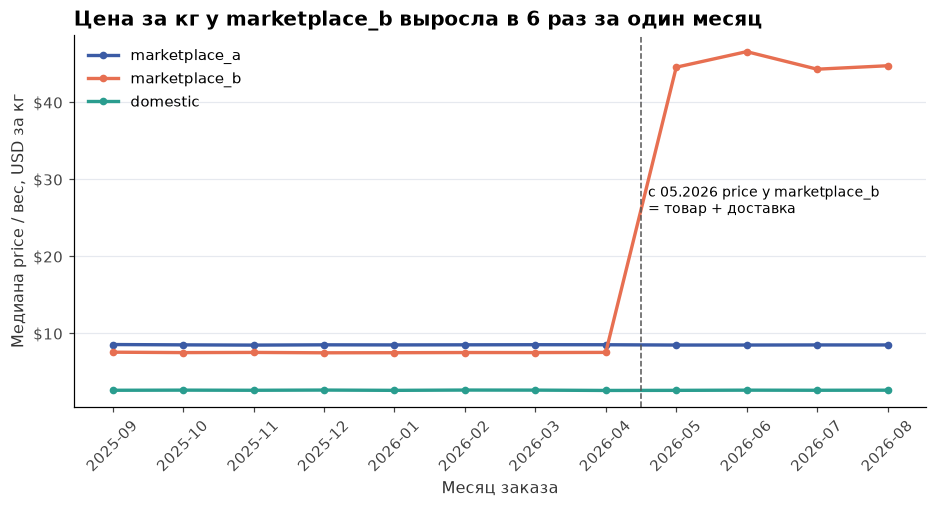

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.4))
colors = {"marketplace_a": pf.COLORS["main"], "marketplace_b": pf.COLORS["accent"], "domestic": pf.COLORS["ok"]}
for ch in ["marketplace_a", "marketplace_b", "domestic"]:
    ax.plot(ppk.index, ppk[ch], marker="o", ms=4, lw=2.2, color=colors[ch], label=ch)
ax.axvline(list(ppk.index).index("2026-05") - 0.5, color="#555555", ls="--", lw=1)
ax.text(list(ppk.index).index("2026-05") - 0.4, ppk.values.max() * 0.55, "с 05.2026 price у marketplace_b\n= товар + доставка", fontsize=9)
pf.usd_axis(ax)
ax.set_ylabel("Медиана price / вес, USD за кг")
ax.set_xlabel("Месяц заказа")
jump = ppk.loc["2026-05":, "marketplace_b"].mean() / ppk.loc[:"2026-04", "marketplace_b"].mean()
ax.set_title(f"Цена за кг у marketplace_b выросла в {jump:.0f} раз за один месяц")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left")
pf.save(fig, "01_price_per_kg")
plt.show()

In [11]:
alert = q("price_jump_alert")
alert

,channel,month,ppk,ppk_prev3,change
0,marketplace_b,2026-05-01,44.559,7.515,4.929
1,marketplace_b,2026-06-01,46.580,7.534,5.182


Тарифы не меняются в разы за месяц. Проверка "цена за кг против медианы трёх прошлых месяцев" ловит такую смену сразу, в первом же месяце.

Пока источник не исправлен, вес канала честнее считать по числу заказов, а не по сумме price:

In [12]:
cs = q("channel_share")
cs["month_s"] = cs["month"].dt.strftime("%Y-%m")
cs[["month_s", "share_by_price", "share_by_orders"]]

,month_s,share_by_price,share_by_orders
0,2025-09,0.297,0.289
1,2025-10,0.305,0.300
2,2025-11,0.315,0.301
3,2025-12,0.302,0.298
4,2026-01,0.300,0.292
5,2026-02,0.317,0.301
6,2026-03,0.317,0.308
7,2026-04,0.315,0.300
8,2026-05,0.720,0.301
9,2026-06,0.723,0.300


In [13]:
after = cs[cs["month"] >= "2026-05-01"]
before = cs[cs["month"] < "2026-05-01"]
print(f"Доля marketplace_b по price: до мая {before['share_by_price'].mean():.0%}, с мая {after['share_by_price'].mean():.0%}")
print(f"Доля marketplace_b по заказам: до мая {before['share_by_orders'].mean():.0%}, с мая {after['share_by_orders'].mean():.0%}")
mb_rev_infl = rv.loc[rv["month"] >= "2026-05-01", "booked_dedup"].sum() / rv.loc[rv["month"] >= "2026-05-01", "booked_clean"].sum() - 1
print(f"Общая выручка с мая по сырому price (после дедупа) завышена на {mb_rev_infl:.0%}")

Доля marketplace_b по price: до мая 31%, с мая 72%
Доля marketplace_b по заказам: до мая 30%, с мая 30%
Общая выручка с мая по сырому price (после дедупа) завышена на 148%


## 3. Статус оплаты и незрелый месяц

Доставка оплачивается при получении. Заказ, сделанный 10 дней назад, скорее всего ещё едет, и у него `payment_status = 1`. Поэтому выручка по оплаченным заказам за текущий и прошлый месяц всегда ниже, чем будет потом.

In [14]:
sm = q("status_by_month")
sm["month_s"] = sm["month"].dt.strftime("%Y-%m")
sm["paid_to_booked"] = sm["revenue_paid"] / sm["revenue_booked"]
sm[["month_s", "share_paid", "share_unpaid", "share_cancelled", "revenue_paid", "revenue_booked", "paid_to_booked"]]

,month_s,share_paid,share_unpaid,share_cancelled,revenue_paid,revenue_booked,paid_to_booked
0,2026-03,0.970,0.003,0.027,"26,690.480","26,762.630",0.997
1,2026-04,0.976,0.003,0.022,"26,022.610","26,101.230",0.997
2,2026-05,0.972,0.004,0.024,"27,932.020","27,985.400",0.998
3,2026-06,0.973,0.003,0.024,"28,043.880","28,123.370",0.997
4,2026-07,0.969,0.005,0.026,"29,906.720","30,069.420",0.995
5,2026-08,0.914,0.062,0.024,"27,300.940","29,275.110",0.933
6,2026-09,0.488,0.477,0.034,"7,034.940","13,941.440",0.505


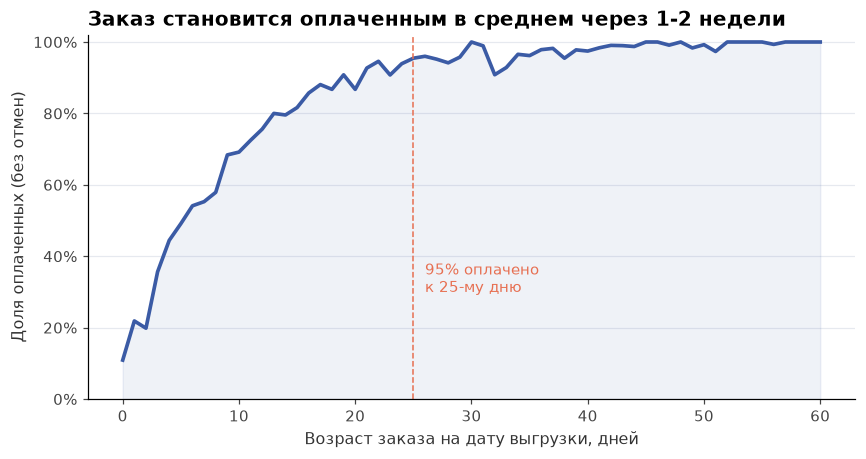

In [15]:
pa = q("paid_by_age")
pa = pa[pa["age_days"] <= 60]
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(pa["age_days"], pa["share_paid"], color=pf.COLORS["main"], lw=2.4)
ax.fill_between(pa["age_days"], pa["share_paid"], color=pf.COLORS["main"], alpha=0.08)
pf.pct_axis(ax)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Возраст заказа на дату выгрузки, дней")
ax.set_ylabel("Доля оплаченных (без отмен)")
d95 = int(pa.loc[pa["share_paid"] >= 0.95, "age_days"].min())
ax.axvline(d95, color=pf.COLORS["accent"], ls="--", lw=1)
ax.text(d95 + 1, 0.3, f"95% оплачено\nк {d95}-му дню", color=pf.COLORS["accent"], fontsize=9.5)
ax.set_title("Заказ становится оплаченным в среднем через 1-2 недели")
pf.save(fig, "02_paid_by_age")
plt.show()

In [16]:
aug = sm[sm["month_s"] == "2026-08"].iloc[0]
sep = sm[sm["month_s"] == "2026-09"].iloc[0]
print(f"Август: оплачено {aug['paid_to_booked']:.0%} от выручки к получению, сентябрь (1-14): {sep['paid_to_booked']:.0%}")

Август: оплачено 93% от выручки к получению, сентябрь (1-14): 50%


Правило для отчётов:
- закрытые месяцы: выручка = `SUM(price) WHERE payment_status = 2`;
- текущий месяц и прошлый, если с его конца прошло меньше ~3 недель: показывать выручку к получению (статусы 1 и 2) и отдельно долю уже оплаченной;
- статус 0 (отмены и тестовые заказы) не входит никуда.

## 4. Проверки в стиле тестов

`checks.sql` содержит проверки, каждая возвращает число нарушений. `run_checks.py` запускает их и падает с кодом 1, если что-то не так. Прогоняем на трёх версиях таблицы.

In [17]:
tables = {"orders_raw": "сырая", "orders_dedup": "после дедупа", "orders": "чистая витрина"}
res_checks = {}
for t, label in tables.items():
    res_checks[label] = dict(run_checks(t, con))
checks_df = pd.DataFrame(res_checks)
checks_df

,сырая,после дедупа,чистая витрина
unique_key,9675,0,0
status_domain,0,0,0
price_positive,0,0,0
updated_after_created,0,0,0
user_exists,0,0,0
order_after_registration,0,0,0
price_per_kg_stable,2,2,0
closed_month_paid,43,0,0


In [18]:
# чистая витрина обязана проходить все проверки
assert (checks_df["чистая витрина"] == 0).all(), checks_df[checks_df["чистая витрина"] > 0]
# сырая таблица обязана их проваливать: иначе проверки ничего не ловят
assert checks_df.loc["unique_key", "сырая"] > 0
assert checks_df.loc["price_per_kg_stable", "после дедупа"] > 0
assert checks_df.loc["closed_month_paid", "сырая"] > 0
# после дедупа и до смены поля сырая таблица совпадает с витриной до цента
pre_check = rv[rv["month"] < "2026-05-01"]
assert np.allclose(pre_check["booked_dedup"], pre_check["booked_clean"]), "дедуп не сходится с витриной"
print("все проверки прошли")

все проверки прошли


In [19]:
res = {
    "rows_raw": ov.loc[0, "rows_raw"],
    "keys": ov.loc[0, "keys_created_order"],
    "extra_versions": ov.loc[0, "extra_versions"],
    "extra_versions_share": ov.loc[0, "extra_versions"] / ov.loc[0, "keys_created_order"],
    "dup_revenue_inflation": dup_infl,
    "dup_orders_inflation": orders_infl,
    "wrong_key_lost_orders": lost_wrong,
    "wrong_key_lost_share": lost_wrong / wrong["orders_true"].sum(),
    "unpaid_overstated": unp_over,
    "mb_ppk_jump": jump,
    "mb_share_price_before": before["share_by_price"].mean(),
    "mb_share_price_after": after["share_by_price"].mean(),
    "mb_share_orders_before": before["share_by_orders"].mean(),
    "mb_share_orders_after": after["share_by_orders"].mean(),
    "revenue_inflation_since_may": mb_rev_infl,
    "paid_95_day": d95,
    "aug_paid_to_booked": aug["paid_to_booked"],
    "sep_paid_to_booked": sep["paid_to_booked"],
    "checks_total": len(checks_df),
    "checks_failed_raw": int((checks_df["сырая"] > 0).sum()),
}
pf.save_results(res)
pd.Series(res)

rows_raw                      81,915.000
keys                          72,240.000
extra_versions                 9,675.000
extra_versions_share               0.134
dup_revenue_inflation              0.136
dup_orders_inflation               0.139
wrong_key_lost_orders          1,500.000
wrong_key_lost_share               0.021
unpaid_overstated                  4.941
mb_ppk_jump                        5.993
mb_share_price_before              0.309
mb_share_price_after               0.721
mb_share_orders_before             0.299
mb_share_orders_after              0.303
revenue_inflation_since_may        1.475
paid_95_day                       25.000
aug_paid_to_booked                 0.933
sep_paid_to_booked                 0.505
checks_total                       8.000
checks_failed_raw                  3.000
dtype: float64